In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu
import math
%pip install lightgbm
import xgboost as xgb
import lightgbm as lgb


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 325.1 kB/s eta 0:00:05
   - -------------------------------------- 0.1/1.5 MB 409.6 kB/s eta 0:00:04
   --- ------------------------------------ 0.1/1.5 MB 595.3 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 514.3 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/1.5 MB 655.4 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.5 MB 621.6 kB/s eta 0:00:03
   ------ --------------------------------- 0.2/1.5 MB 654.9 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 681.0 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.5 MB 701.4 kB/s eta 0:00:02
   ---------- ----------------------------- 0.4/1.5 MB 757.8 kB/s eta 0:00:02
   --------

In [3]:
df_full = pd.read_csv("bank+marketing/bank/bank-full.csv", sep=";")

**Thông tin về các cột**

In [4]:
print(df_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


**Vẽ phân phối biến liên tục**

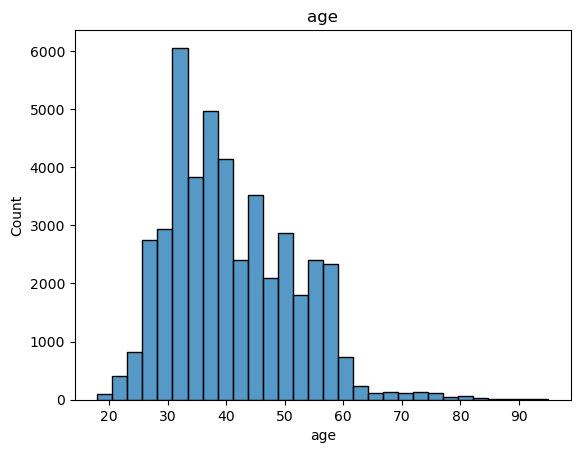

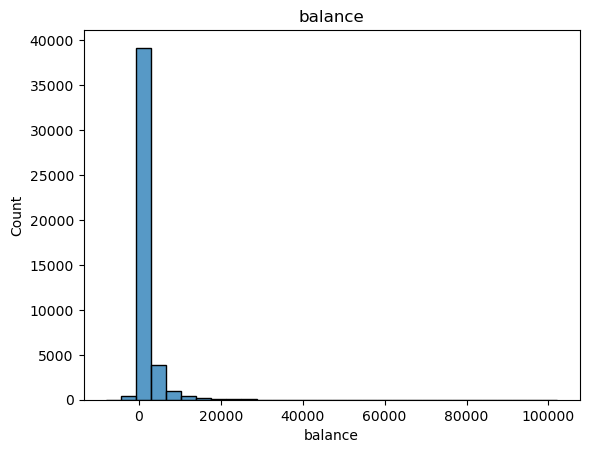

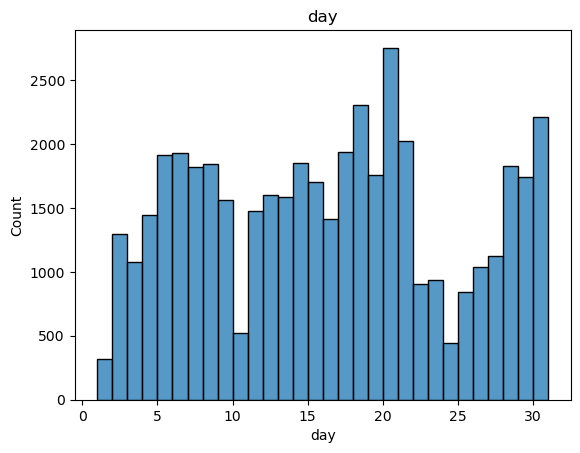

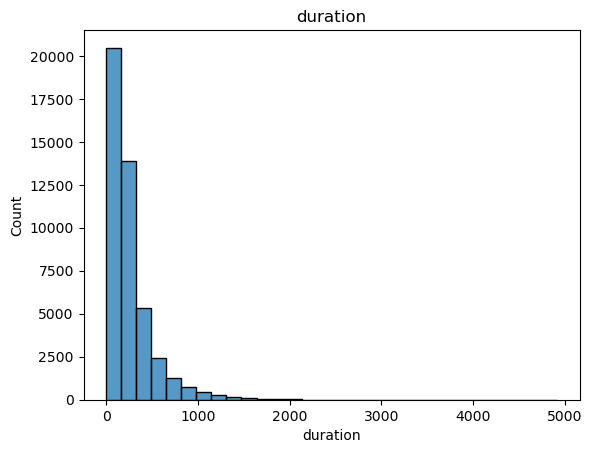

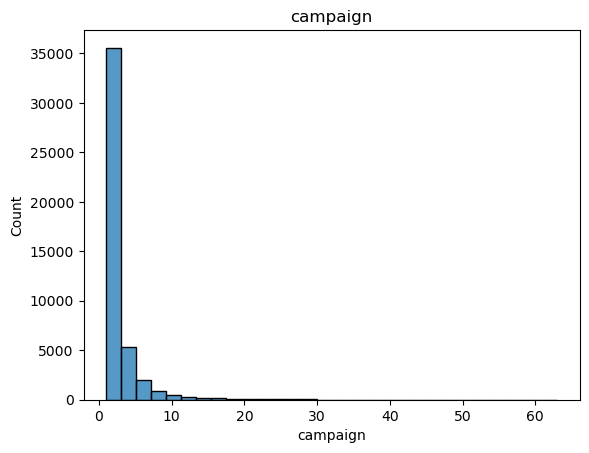

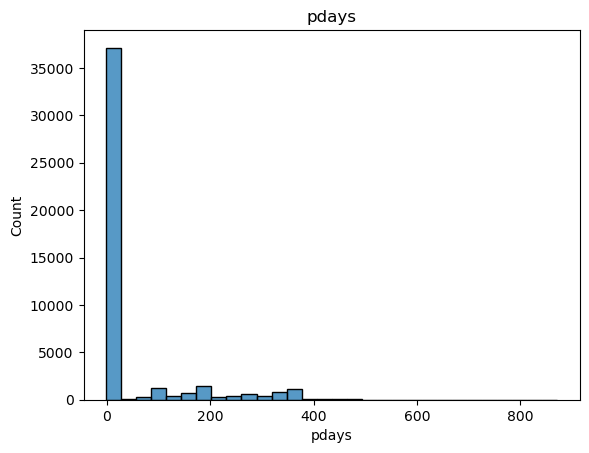

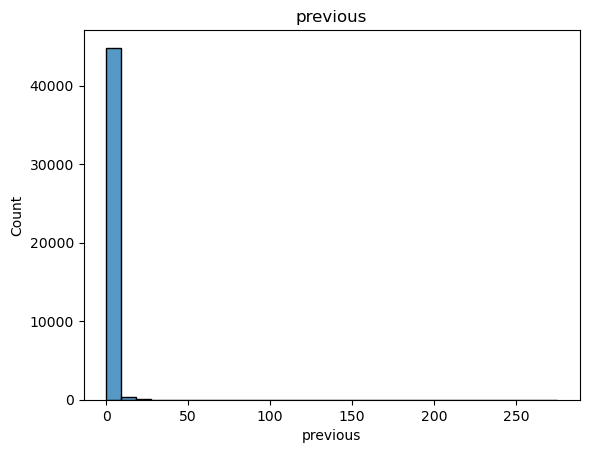

In [6]:
cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

for col in cols:
    plt.figure()
    sns.histplot(df_full[col], bins=30)
    plt.title(col)
    plt.show()

**Xem giá trị tb, trung vị biến liên tục đối với mục tiêu yes/no**
(bỏ days và duration)

<>:12: SyntaxWarning: invalid escape sequence '\Q'
<>:12: SyntaxWarning: invalid escape sequence '\Q'
C:\Users\acer\AppData\Local\Temp\ipykernel_40764\2441391451.py:12: SyntaxWarning: invalid escape sequence '\Q'
  print("\Quantile by y:")


y                         no          yes
age      mean      40.838986    41.670070
         median    39.000000    38.000000
balance  mean    1303.714969  1804.267915
         median   417.000000   733.000000
duration mean     221.182806   537.294574
         median   164.000000   426.000000
campaign mean       2.846350     2.141047
         median     2.000000     2.000000
pdays    mean      36.421372    68.702968
         median    -1.000000    -1.000000
previous mean       0.502154     1.170354
         median     0.000000     0.000000
\Quantile by y:
           age  balance  duration  campaign  pdays  previous
y                                                           
no  0.25  33.0     58.0      95.0       1.0   -1.0       0.0
    0.50  39.0    417.0     164.0       2.0   -1.0       0.0
    0.75  48.0   1345.0     279.0       3.0   -1.0       0.0
yes 0.25  31.0    210.0     244.0       1.0   -1.0       0.0
    0.50  38.0    733.0     426.0       2.0   -1.0       0.0
    0.75  5

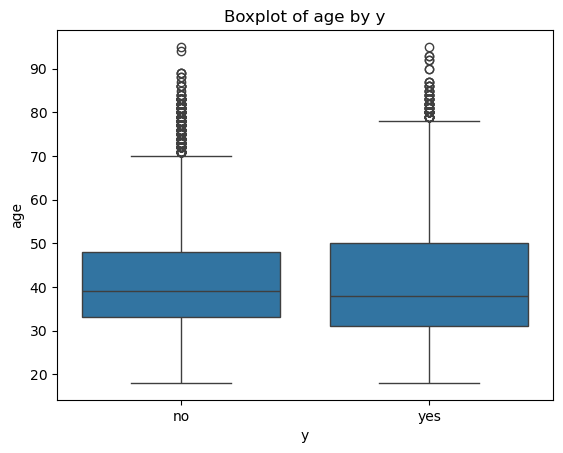

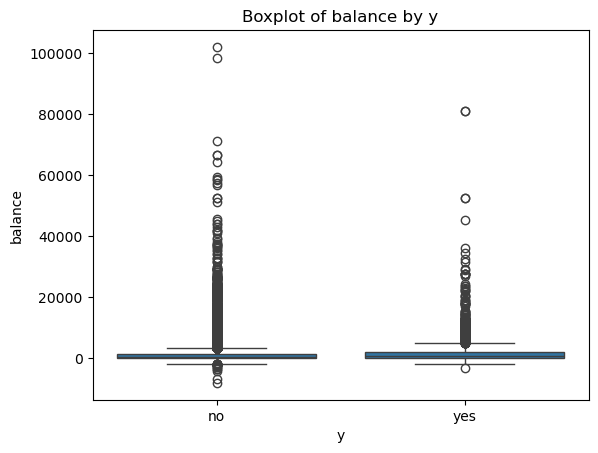

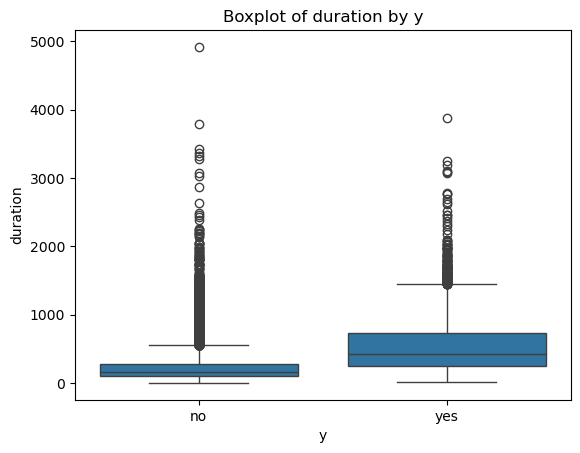

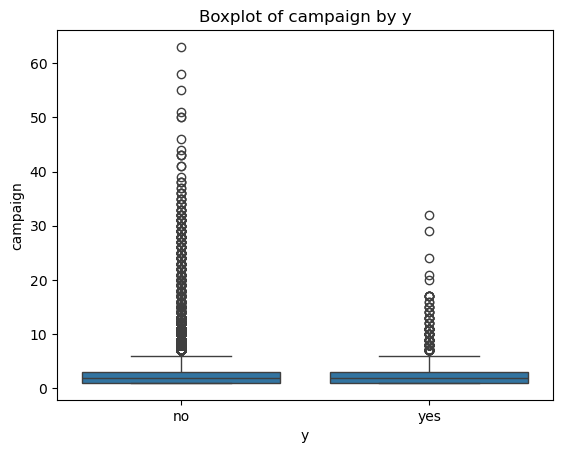

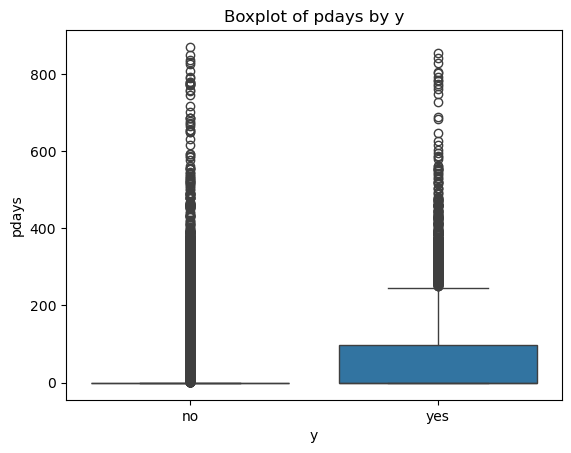

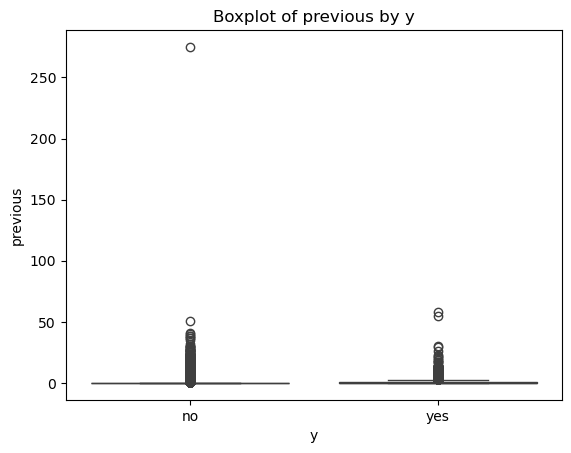


Mann-Whitney U test p-values:
age: p-value = 0.06282
balance: p-value = 0.00000
duration: p-value = 0.00000
campaign: p-value = 0.00000
pdays: p-value = 0.00000
previous: p-value = 0.00000


In [14]:
# =========================
# 1. Lấy biến liên tục (numeric)
# =========================
cols = df_full.select_dtypes(include="number").columns.drop("day")

# =========================
# 2. So sánh thống kê cơ bản (mean, median)
# ⚠️ mean có thể bị lệch nếu có outlier
# =========================
result = df_full.groupby("y")[cols].agg(["mean", "median"])
print(result.T)
print("\Quantile by y:")
print(df_full.groupby("y")[cols].quantile([0.25, 0.5, 0.75]))


# =========================
# 3. Kiểm tra phân phối (tránh bị lệch)
# → dùng boxplot để xem median + outlier
# =========================
for col in cols:
    plt.figure()
    sns.boxplot(x="y", y=col, data=df_full)
    plt.title(f"Boxplot of {col} by y")
    plt.show()


# =========================
# 4. Kiểm định thống kê (Mann-Whitney U test)
# → kiểm tra khác biệt yes/no có ý nghĩa không
# =========================
print("\nMann-Whitney U test p-values:")

for col in cols:
    group_yes = df_full[df_full["y"] == "yes"][col]
    group_no = df_full[df_full["y"] == "no"][col]

    stat, p = mannwhitneyu(group_yes, group_no)

    print(f"{col}: p-value = {p:.5f}")

Các biến số sẽ phân tích: ['age', 'balance', 'campaign', 'pdays', 'previous']

--- Thống kê mô tả (Mean, Median, Std) theo nhóm y ---
y                         no          yes
age      mean      40.838986    41.670070
         median    39.000000    38.000000
         std       10.172662    13.497781
balance  mean    1303.714969  1804.267915
         median   417.000000   733.000000
         std     2974.195473  3501.104777
campaign mean       2.846350     2.141047
         median     2.000000     2.000000
         std        3.212767     1.921826
pdays    mean      36.421372    68.702968
         median    -1.000000    -1.000000
         std       96.757135   118.822266
previous mean       0.502154     1.170354
         median     0.000000     0.000000
         std        2.256771     2.553272

--- Phân vị (Quantiles: 25%, 50%, 75%) theo nhóm y ---
           age  balance  campaign  pdays  previous
y                                                 
no  0.25  33.0     58.0       1.0   

C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
C:\Users\acer\AppData\Local\Temp\ipykernel_40764\845860139.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[

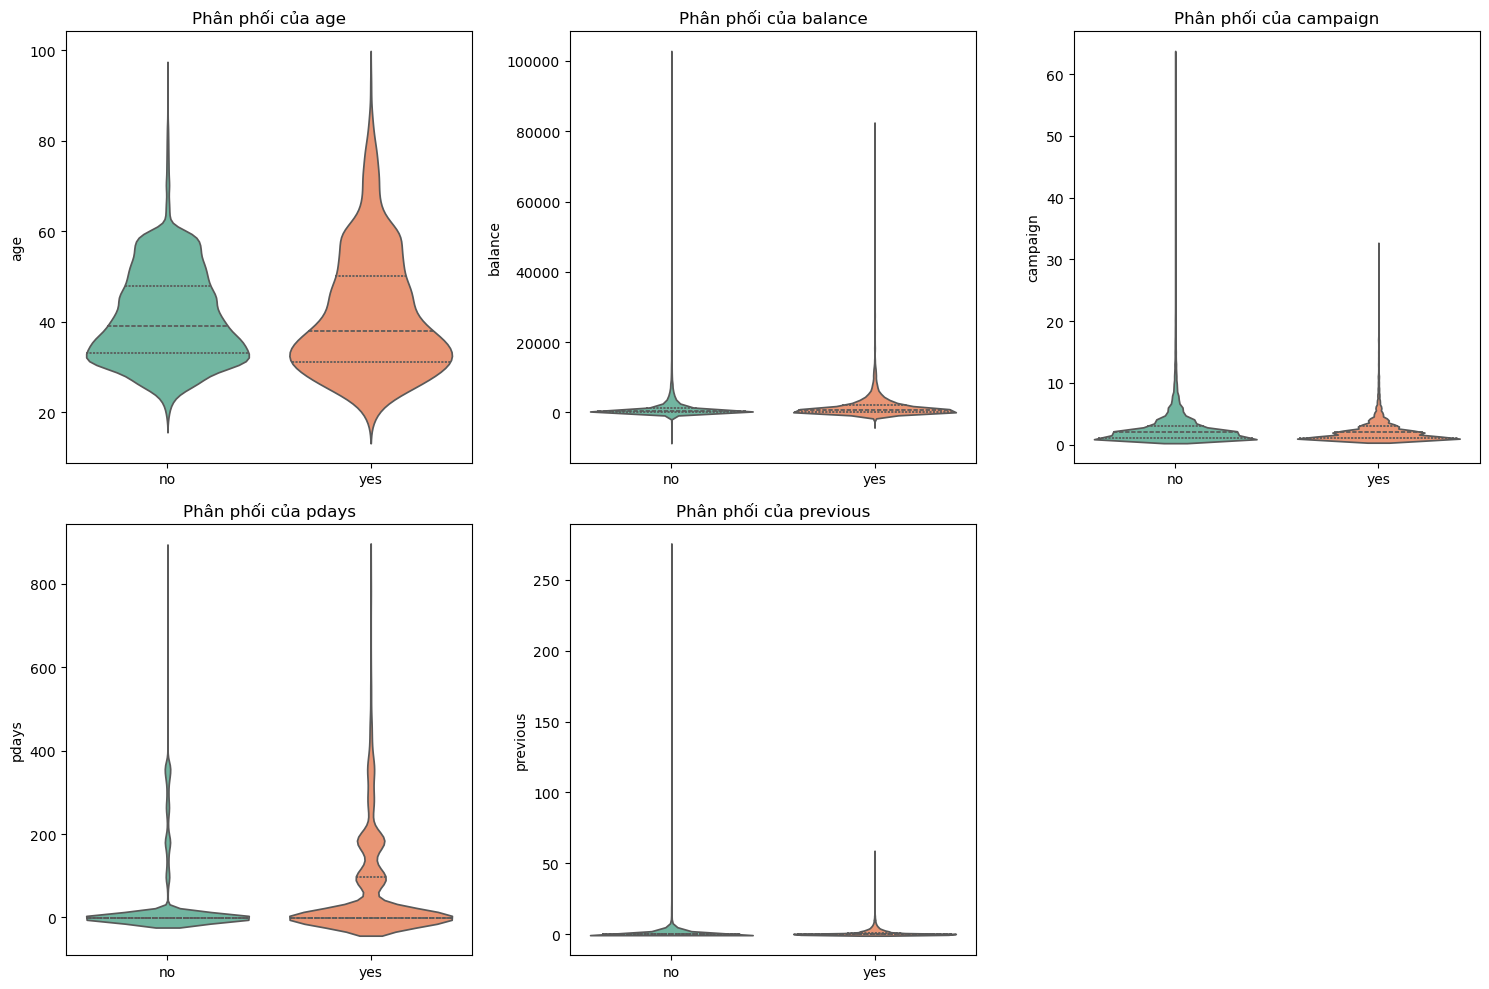


--- Mann-Whitney U test p-values ---
age            : p-value = 0.06282 (Không ý nghĩa)
balance        : p-value = 0.00000 (Có ý nghĩa)
campaign       : p-value = 0.00000 (Có ý nghĩa)
pdays          : p-value = 0.00000 (Có ý nghĩa)
previous       : p-value = 0.00000 (Có ý nghĩa)


In [21]:
# =========================
# 1. Lấy biến liên tục (loại bỏ day và duration)
# =========================
exclude_cols = ["day", "duration"]
# Lọc lấy các cột dạng số và không nằm trong danh sách loại trừ
cols = [c for c in df_full.select_dtypes(include="number").columns if c not in exclude_cols]

print(f"Các biến số sẽ phân tích: {cols}\n")

# =========================
# 2. So sánh thống kê mô tả
# =========================
print("--- Thống kê mô tả (Mean, Median, Std) theo nhóm y ---")
result_stats = df_full.groupby("y")[cols].agg(["mean", "median", "std"])
print(result_stats.T)

print("\n--- Phân vị (Quantiles: 25%, 50%, 75%) theo nhóm y ---")
# Transpose (.T) để bảng hiển thị dọc, dễ so sánh các biến hơn
result_quantiles = df_full.groupby("y")[cols].quantile([0.25, 0.5, 0.75])
print(result_quantiles)

# =========================
# 3. Trực quan hóa (Violin Plot trên Lưới)
# -> Giúp xem cả phân phối, median, outlier và tiết kiệm bộ nhớ
# =========================
num_cols = len(cols)
cols_per_row = 3 # Số lượng biểu đồ trên 1 hàng
rows = math.ceil(num_cols / cols_per_row)

# Khởi tạo khung vẽ tổng thể
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
axes = axes.flatten() # Trải phẳng mảng lưới để dễ lặp qua từng ô

for i, col in enumerate(cols):
    # Dùng violinplot với inner="quartile" để hiện luôn các mốc phân vị bên trong
    sns.violinplot(x="y", y=col, data=df_full, inner="quartile", ax=axes[i], palette="Set2")
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_xlabel("") # Ẩn tên trục x để đỡ rối

# Xóa các ô trống dư thừa nếu số lượng biến không lấp đầy hàng cuối cùng
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =========================
# 4. Kiểm định thống kê (Mann-Whitney U test)
# =========================
print("\n--- Mann-Whitney U test p-values ---")
for col in cols:
    # Lọc dữ liệu theo nhóm
    group_yes = df_full[df_full["y"] == "yes"][col]
    group_no = df_full[df_full["y"] == "no"][col]
    
    # Bỏ qua các giá trị NaN (nếu có) để kiểm định không bị lỗi
    stat, p = mannwhitneyu(group_yes.dropna(), group_no.dropna(), alternative='two-sided')
    
    # Đánh giá nhanh kết quả
    status = "Có ý nghĩa" if p < 0.05 else "Không ý nghĩa"
    print(f"{col:15}: p-value = {p:.5f} ({status})")

**Biến phân loại so với tương quan yes**


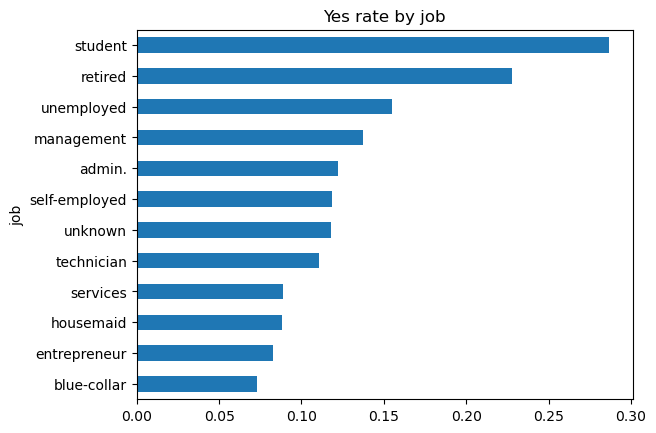

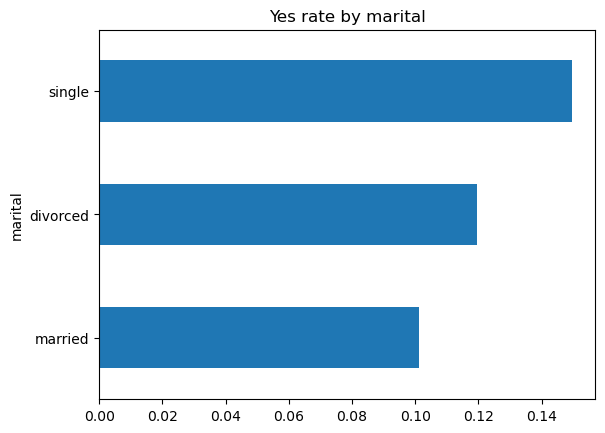

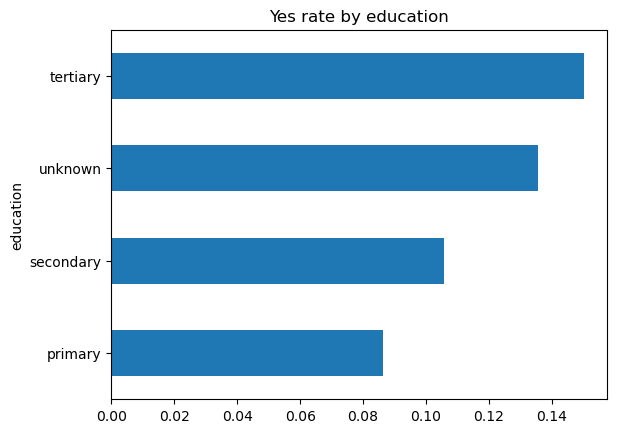

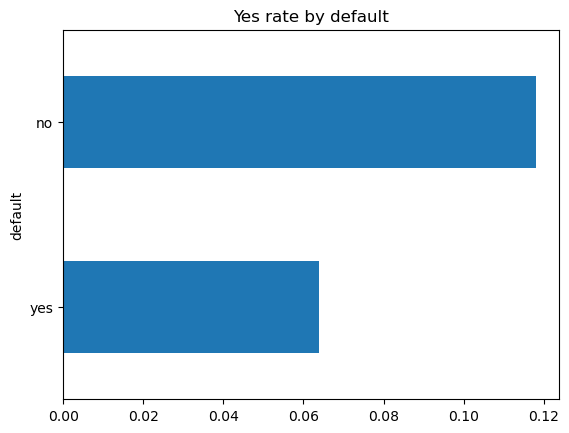

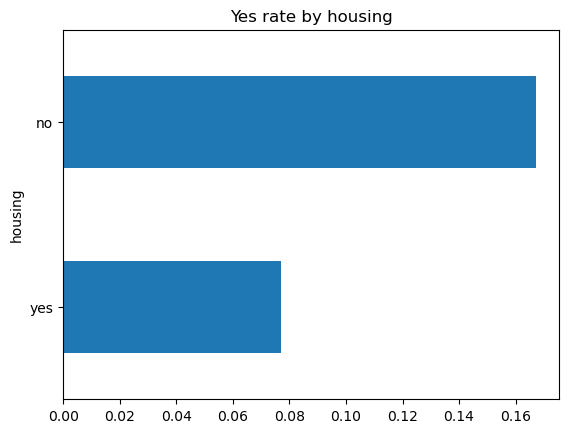

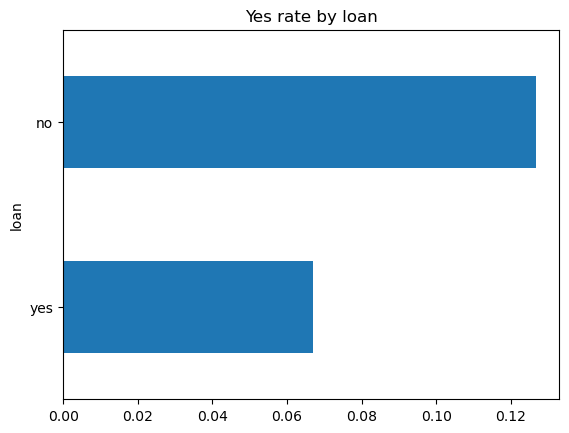

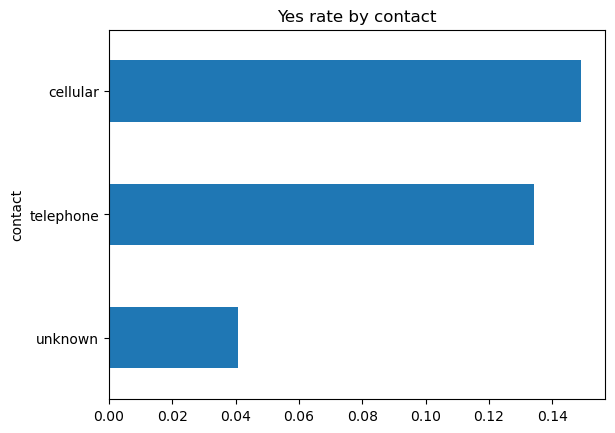

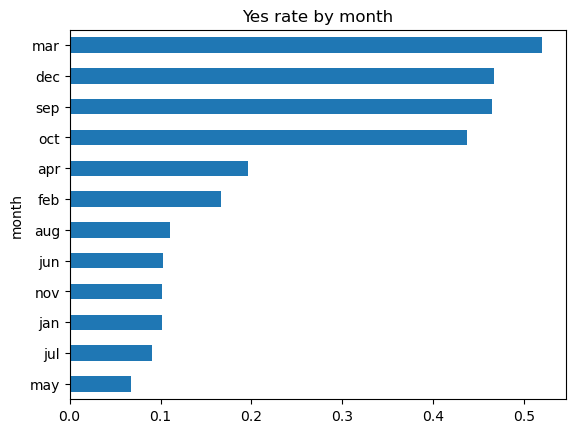

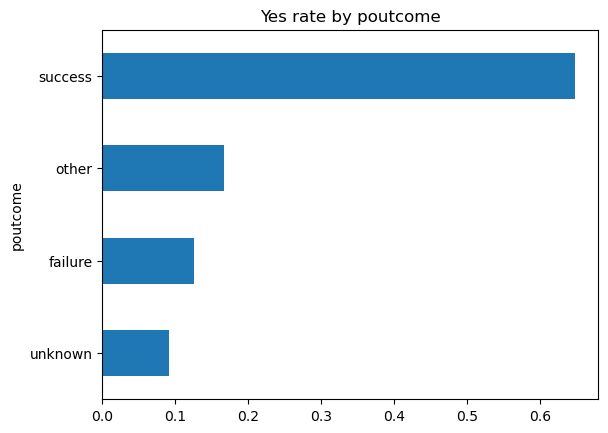

In [11]:
cat_cols = df_full.select_dtypes(include="object").columns.drop("y")

for col in cat_cols:
    table = pd.crosstab(df_full[col], df_full["y"], normalize="index")
    yes_rate = table["yes"].sort_values()

    plt.figure()
    yes_rate.plot(kind="barh")
    plt.title(f"Yes rate by {col}")
    plt.show()

**Biến phân loại so với tương quan no**


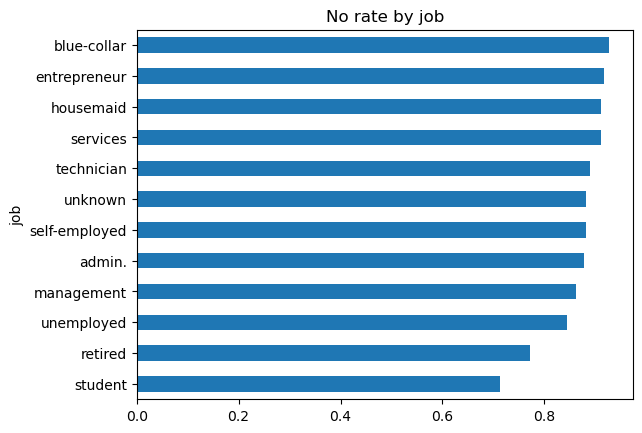

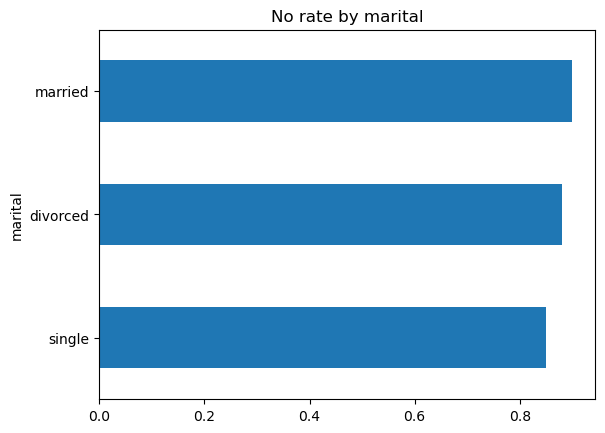

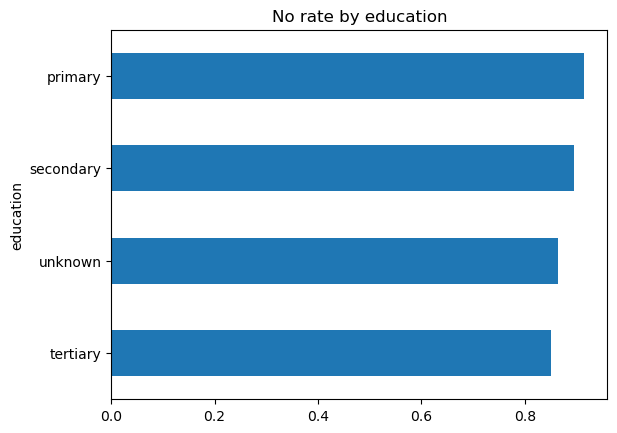

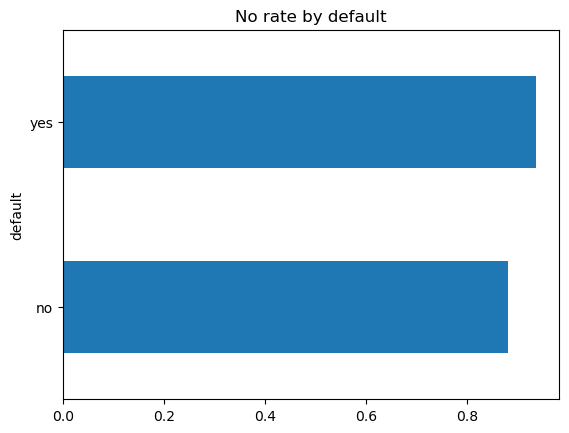

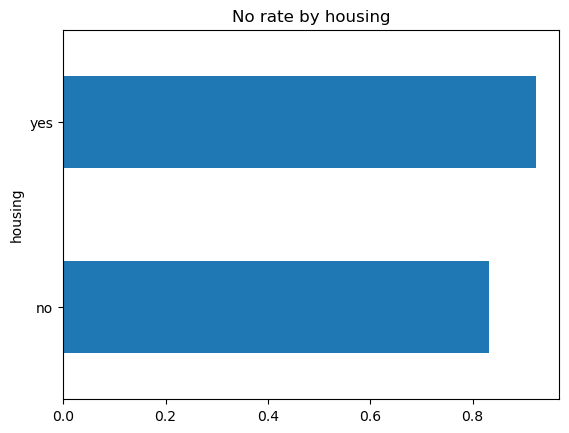

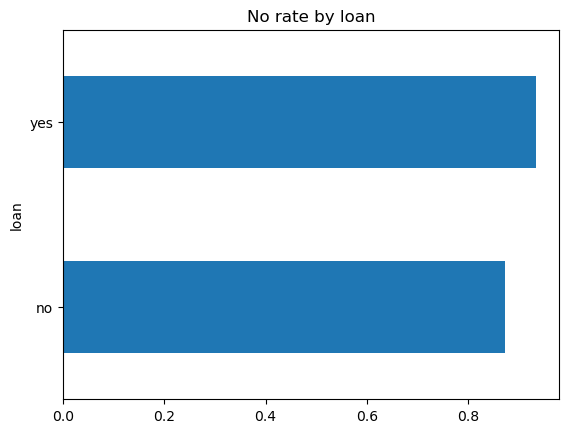

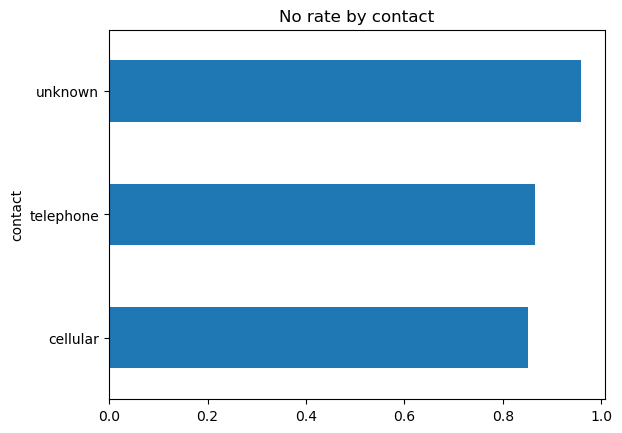

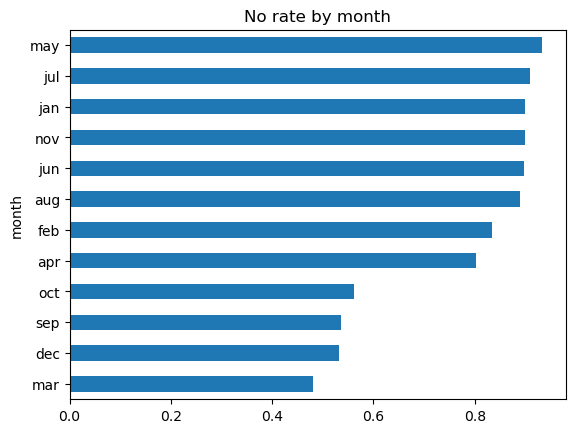

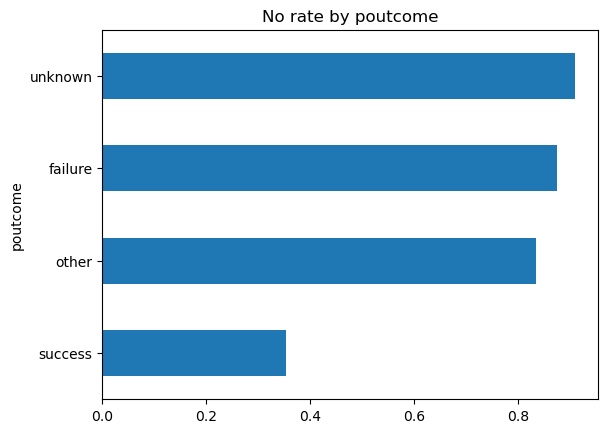

In [15]:
cat_cols = df_full.select_dtypes(include="object").columns.drop("y")

for col in cat_cols:
    table = pd.crosstab(df_full[col], df_full["y"], normalize="index")
    yes_rate = table["no"].sort_values()

    plt.figure()
    yes_rate.plot(kind="barh")
    plt.title(f"No rate by {col}")
    plt.show()

--- 1. Dữ liệu sau khi chuẩn hóa Z-score (5 dòng đầu) ---
        age   balance  campaign     pdays  previous
0  1.606965  0.256419 -0.569351 -0.411453  -0.25194
1  0.288529 -0.437895 -0.569351 -0.411453  -0.25194
2 -0.747384 -0.446762 -0.569351 -0.411453  -0.25194
3  0.571051  0.047205 -0.569351 -0.411453  -0.25194
4 -0.747384 -0.447091 -0.569351 -0.411453  -0.25194 



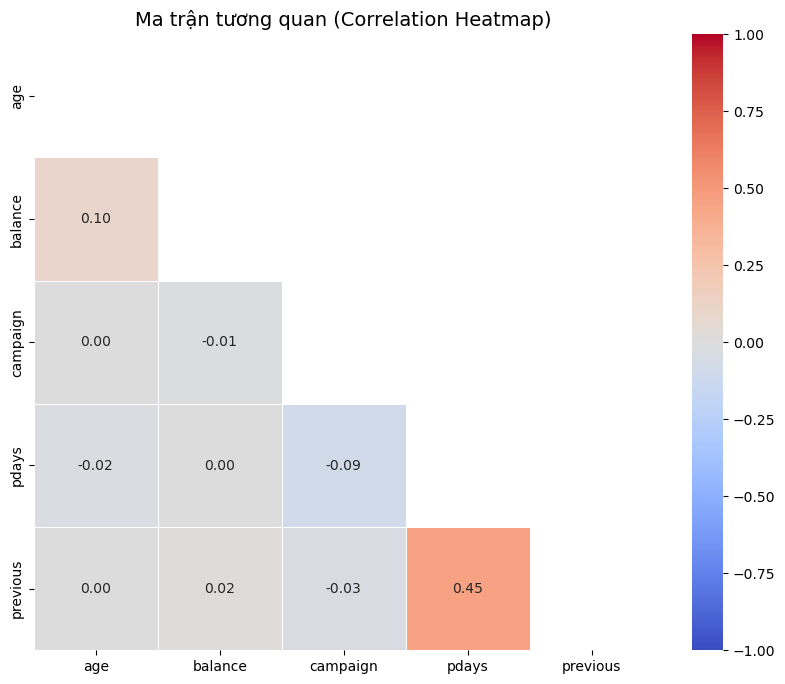

--- 2. Hệ số phóng đại phương sai (VIF) ---
pdays          : VIF =  1.27 -> 🟢 An toàn
previous       : VIF =  1.26 -> 🟢 An toàn
age            : VIF =  1.01 -> 🟢 An toàn
balance        : VIF =  1.01 -> 🟢 An toàn
campaign       : VIF =  1.01 -> 🟢 An toàn


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Đảm bảo 'cols' là danh sách các biến liên tục bạn đã lọc ở bước trước
# cols = [c for c in df_full.select_dtypes(include="number").columns if c not in ["day", "duration"]]

# ==========================================
# Bước 1: Chuẩn hóa dữ liệu bằng Z-score
# ==========================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_full[cols]), columns=cols)

print("--- 1. Dữ liệu sau khi chuẩn hóa Z-score (5 dòng đầu) ---")
print(df_scaled.head(), "\n")

# ==========================================
# Bước 2: Ma trận tương quan (Pearson Correlation)
# ==========================================
corr_matrix = df_scaled.corr()

plt.figure(figsize=(10, 8))
# Tạo mask để ẩn nửa trên của ma trận (vì nó đối xứng, ẩn đi cho đỡ rối mắt)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Vẽ Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", 
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan (Correlation Heatmap)", fontsize=14)
plt.show()

# ==========================================
# Bước 3: Kiểm tra Đa cộng tuyến bằng VIF (Variance Inflation Factor)
# ==========================================
print("--- 2. Hệ số phóng đại phương sai (VIF) ---")

# Khởi tạo bảng chứa kết quả VIF
vif_data = pd.DataFrame()
vif_data["Biến (Feature)"] = df_scaled.columns

# Tính VIF cho từng biến số
# Lưu ý: Vì dữ liệu đã chuẩn hóa Z-score (mean=0), ta có thể tính trực tiếp mà không cần thêm hằng số (add_constant)
vif_data["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

# Sắp xếp VIF giảm dần để dễ rà soát
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# In kết quả và đánh giá tự động
for index, row in vif_data.iterrows():
    vif_val = row["VIF"]
    feature = row["Biến (Feature)"]
    
    # Đặt ngưỡng cảnh báo: VIF > 5 là đáng lo ngại, VIF > 10 là đa cộng tuyến rất nặng
    if vif_val >= 10:
        status = "🔴 Đa cộng tuyến RẤT NẶNG (Nên loại bỏ)"
    elif vif_val >= 5:
        status = "🟡 Nguy cơ cao (Cần xem xét)"
    else:
        status = "🟢 An toàn"
        
    print(f"{feature:15}: VIF = {vif_val:5.2f} -> {status}")

**MODEL**


chia dữ liệu 80/20, stratified. Lưu ý: ở đây k sử dụng LabelEncoding vì làm mô hình sai lệch khi cho rằng một giá trị chữ (phân loại) như student =1 sẽ thua gấp đôi technician =2. Dùng One-hot Encoding cho biến phân loại, và Z-Score cho biến liên tục

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==========================================
# 1. Tiền xử lý cơ bản, loại bỏ các cột không cần thiết
# ==========================================
df = df_full.drop(columns=['day', 'duration'])

X = df.drop(columns=['y'])
y = df['y']

# ==========================================
# 2. Phân loại cột Số và cột Chữ
# ==========================================
# Lấy danh sách này NGAY TỪ ĐẦU để lát nữa biết đường chỉ scale các cột số gốc
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ==========================================
# 3. Mã hóa Dữ liệu (Encoding)
# ==========================================
# A. LabelEncoder cho nhãn y
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y) 

# B. One-Hot Encoding cho tập X
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

# ==========================================
# 4. Chia tập Train / Test (Stratified)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.2,       
    stratify=y_encoded,  
    random_state=42      
)

# Tạo bản sao độc lập để Pandas không báo lỗi SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# ==========================================
# 5. Chuẩn hóa Z-score (StandardScaler)
# ==========================================
scaler = StandardScaler()

# CHÚ Ý: Chỉ fit (tính mean, std) trên tập Train và transform luôn
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Đối với tập Test, CHỈ transform dựa trên mean và std đã học từ tập Train
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ==========================================
# 6. Kiểm tra lại kết quả
# ==========================================
print("✅ HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHO LOGISTIC REGRESSION!\n")

print("--- Thống kê vài cột số trong X_train sau Z-score (Mean ~ 0, Std ~ 1) ---")
print(X_train[num_cols].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\n--- Kích thước dữ liệu cuối cùng ---")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

✅ HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHO LOGISTIC REGRESSION!

--- Thống kê vài cột số trong X_train sau Z-score (Mean ~ 0, Std ~ 1) ---
        age  balance  campaign  pdays  previous
mean -0.000   -0.000     0.000  0.000    -0.000
std   1.000    1.000     1.000  1.000     1.000
min  -2.154   -3.058    -0.568 -0.411    -0.242
max   5.091   32.837    19.405  8.295   113.926

--- Kích thước dữ liệu cuối cùng ---
X_train: (36168, 40)
X_test : (9043, 40)


Chạy mô hình (có dùng class_weighted để mô hình tập trung vào nhãn yes hơn)

⏳ Đang huấn luyện mô hình Logistic Regression...
✅ HUẤN LUYỆN HOÀN TẤT! DƯỚI ĐÂY LÀ KẾT QUẢ:

--- 1. Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.27      0.63      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043

--- 2. Chỉ số ROC-AUC Score: 0.7722 ---
💡 Đánh giá: Mô hình phân loại TỐT.

--- 3. Ma trận nhầm lẫn (Confusion Matrix) ---


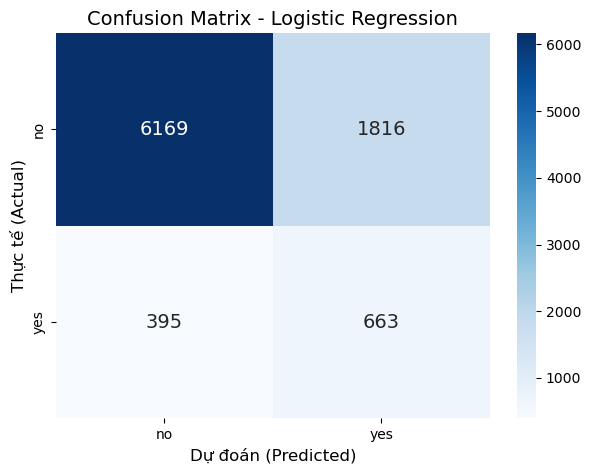

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Khởi tạo và Huấn luyện mô hình (Training)
# ==========================================
print("⏳ Đang huấn luyện mô hình Logistic Regression...")

# Dùng class_weight='balanced' để xử lý data mất cân bằng (Imbalanced Data)
# max_iter=1000 giúp mô hình có đủ thời gian để hội tụ
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# ==========================================
# 2. Dự đoán trên tập Test
# ==========================================
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1] # Lấy xác suất dự đoán là 1 (Yes)

# ==========================================
# 3. Đánh giá Mô hình (Evaluation)
# ==========================================
print("✅ HUẤN LUYỆN HOÀN TẤT! DƯỚI ĐÂY LÀ KẾT QUẢ:\n")

# --- A. Báo cáo phân loại (Classification Report) ---
print("--- 1. Báo cáo phân loại (Classification Report) ---")
# Lấy lại tên nhãn gốc từ LabelEncoder ('no', 'yes') để in cho dễ đọc
target_names = le_y.classes_ 
print(classification_report(y_test, y_pred, target_names=target_names))

# --- B. Đánh giá bằng ROC-AUC ---
# AUC là thang đo rất tốt cho dữ liệu mất cân bằng (1 là hoàn hảo, 0.5 là đoán bừa)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"--- 2. Chỉ số ROC-AUC Score: {auc_score:.4f} ---")
if auc_score >= 0.8:
    print("💡 Đánh giá: Mô hình có khả năng phân loại RẤT TỐT!")
elif auc_score >= 0.7:
    print("💡 Đánh giá: Mô hình phân loại TỐT.")
else:
    print("💡 Đánh giá: Mô hình phân loại TRUNG BÌNH/YẾU.")

# --- C. Ma trận nhầm lẫn (Confusion Matrix) ---
print("\n--- 3. Ma trận nhầm lẫn (Confusion Matrix) ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14}) # Phóng to số cho dễ nhìn
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

Một số pp tinh chỉnh cải thiện FALSE POSITIVE (Mặc dù mô hình baseline ở trên có FALSE NEGATIVE THẤP NHƯNG FALSE POSITIVE CAO -> làm tăng chi phí lãng phí vì phải gọi thêm những thằng tưởng là tiềm năng nhưng k). TUY NHIÊN CHỈ LÀ TEST THÔI VÌ CƠ BẢN THÌ FALSE NEGATIVE mới tạo ra lợi nhuận -> cần tìm điểm cân bằng (nhưng như v quá phức tạp cho baseline nên thôi)

🚀 BẮT ĐẦU CHẠY 4 KỊCH BẢN CẢI THIỆN MÔ HÌNH

⏳ 1. Đang xử lý: Dời ngưỡng quyết định (0.65)...
              precision    recall  f1-score   support

          no       0.93      0.85      0.89      7985
         yes       0.33      0.55      0.41      1058

    accuracy                           0.82      9043
   macro avg       0.63      0.70      0.65      9043
weighted avg       0.86      0.82      0.84      9043

🌟 ROC-AUC Score (Dựa trên xác suất gốc): 0.7722

--------------------------------------------------
⏳ 2. Đang xử lý: Tùy chỉnh trọng số (1:5)...
              precision    recall  f1-score   support

          no       0.93      0.86      0.90      7985
         yes       0.34      0.54      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.82      0.84      9043

🌟 ROC-AUC Score: 0.7722

--------------------------------------------------
⏳ 3. Đang xử lý: Tìm kiếm siêu 

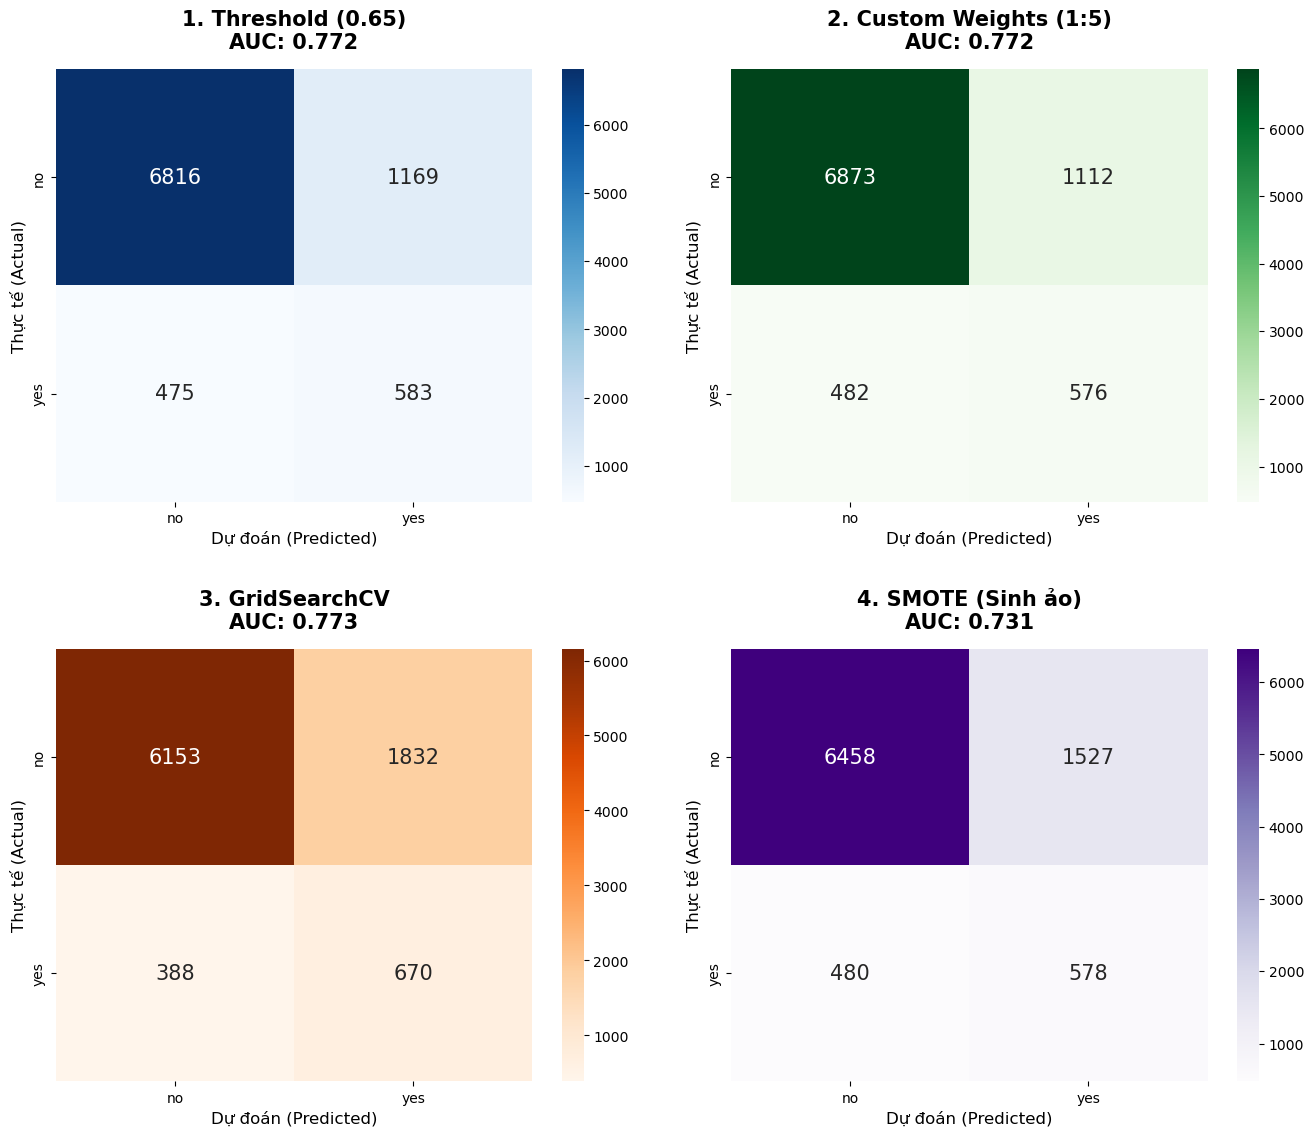

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV

print("="*60)
print("🚀 BẮT ĐẦU CHẠY 4 KỊCH BẢN CẢI THIỆN MÔ HÌNH")
print("="*60 + "\n")

# Lấy lại tên nhãn gốc (nếu bạn chưa định nghĩa thì mặc định là 'no' và 'yes')
try:
    target_names = le_y.classes_
except NameError:
    target_names = ['no', 'yes']

# =====================================================================
# 1. THRESHOLD TUNING (Tăng ngưỡng lên 0.65 để giảm False Positive)
# =====================================================================
print("⏳ 1. Đang xử lý: Dời ngưỡng quyết định (0.65)...")
custom_threshold = 0.55
y_pred_1 = (y_pred_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_1, target_names=target_names))
# Lưu ý: AUC của phương pháp này bằng y hệt Baseline vì AUC đo trên xác suất (y_pred_proba) 
# chứ không đo trên nhãn đã ép ngưỡng.
auc_1 = roc_auc_score(y_test, y_pred_proba)
print(f"🌟 ROC-AUC Score (Dựa trên xác suất gốc): {auc_1:.4f}\n")
print("-" * 50)

# =====================================================================
# 2. CUSTOM CLASS WEIGHTS (Tùy chỉnh phạt sai Yes nhẹ hơn: 1 vs 5)
# =====================================================================
print("⏳ 2. Đang xử lý: Tùy chỉnh trọng số (1:5)...")
log_reg_cw = LogisticRegression(class_weight={0: 1, 1: 6}, max_iter=1000, random_state=42)
log_reg_cw.fit(X_train, y_train)

y_pred_2 = log_reg_cw.predict(X_test)
y_proba_2 = log_reg_cw.predict_proba(X_test)[:, 1] # Lấy xác suất để tính AUC

print(classification_report(y_test, y_pred_2, target_names=target_names))
auc_2 = roc_auc_score(y_test, y_proba_2)
print(f"🌟 ROC-AUC Score: {auc_2:.4f}\n")
print("-" * 50)

# =====================================================================
# 3. GRIDSEARCH CV (Cho máy tự tìm tham số tối ưu)
# =====================================================================
print("⏳ 3. Đang xử lý: Tìm kiếm siêu tham số tối ưu (GridSearchCV)...")
# Đã thu gọn tham số C để máy chạy nhanh hơn
param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear']} 
grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_3 = best_model.predict(X_test)
y_proba_3 = best_model.predict_proba(X_test)[:, 1]

print(f"(Tham số tốt nhất tìm được: {grid_search.best_params_})")
print(classification_report(y_test, y_pred_3, target_names=target_names))
auc_3 = roc_auc_score(y_test, y_proba_3)
print(f"🌟 ROC-AUC Score: {auc_3:.4f}\n")
print("-" * 50)

# =====================================================================
# 4. SMOTE (Sinh dữ liệu ảo để cân bằng hoàn toàn 50/50)
# =====================================================================
print("⏳ 4. Đang xử lý: Cân bằng dữ liệu bằng SMOTE...")
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
    log_reg_smote.fit(X_train_smote, y_train_smote)
    
    y_pred_4 = log_reg_smote.predict(X_test)
    y_proba_4 = log_reg_smote.predict_proba(X_test)[:, 1]
    method_4_title = "4. SMOTE (Sinh ảo)"
    
    print(classification_report(y_test, y_pred_4, target_names=target_names))
    auc_4 = roc_auc_score(y_test, y_proba_4)
    print(f"🌟 ROC-AUC Score: {auc_4:.4f}\n")

except ImportError:
    print("⚠️ CẢNH BÁO: Bạn chưa cài 'imbalanced-learn'. Đang chạy Fallback (Ngưỡng 0.3)...")
    y_pred_4 = (y_pred_proba >= 0.3).astype(int)
    method_4_title = "4. Fallback: Threshold 0.3"
    print(classification_report(y_test, y_pred_4, target_names=target_names))
    auc_4 = roc_auc_score(y_test, y_pred_proba) # AUC không đổi khi chỉnh threshold
    print(f"🌟 ROC-AUC Score (Dựa trên xác suất gốc): {auc_4:.4f}\n")


# =====================================================================
# VẼ BIỂU ĐỒ TỔNG HỢP (GRID 2x2 CONFUSION MATRIX)
# =====================================================================
print("✅ HOÀN TẤT! Đang xuất biểu đồ so sánh...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plots_config = [
    (y_pred_1, f"1. Threshold (0.65)\nAUC: {auc_1:.3f}", axes[0, 0], "Blues"),
    (y_pred_2, f"2. Custom Weights (1:5)\nAUC: {auc_2:.3f}", axes[0, 1], "Greens"),
    (y_pred_3, f"3. GridSearchCV\nAUC: {auc_3:.3f}", axes[1, 0], "Oranges"),
    (y_pred_4, f"{method_4_title}\nAUC: {auc_4:.3f}", axes[1, 1], "Purples")
]

for y_pred_custom, title, ax, cmap in plots_config:
    cm = confusion_matrix(y_test, y_pred_custom)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 15})
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Thực tế (Actual)', fontsize=12)
    ax.set_xlabel('Dự đoán (Predicted)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

**XGBoost**

⏳ Đang huấn luyện XGBoost Baseline (Không kỹ thuật)...
✅ KẾT QUẢ XGBOOST BASELINE:

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.61      0.24      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.61      0.64      9043
weighted avg       0.87      0.89      0.87      9043

🌟 ROC-AUC Score: 0.7732


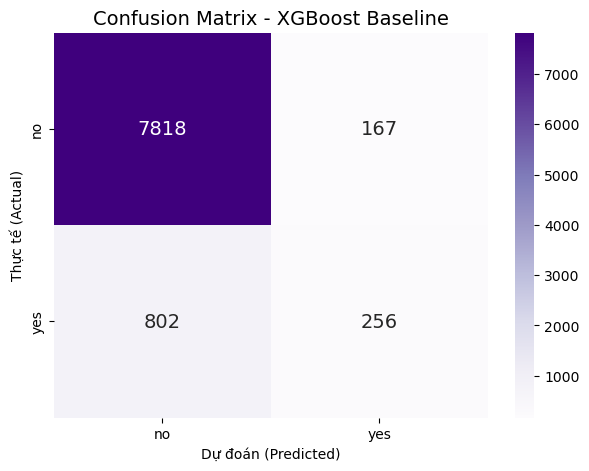

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Khởi tạo và Huấn luyện XGBoost Baseline
# ==========================================
print("⏳ Đang huấn luyện XGBoost Baseline (Không kỹ thuật)...")

# Chỉ để mặc định các tham số cơ bản
xgb_baseline = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)

# ==========================================
# 2. Dự đoán
# ==========================================
y_pred_xgb = xgb_baseline.predict(X_test)
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

# ==========================================
# 3. Đánh giá
# ==========================================
print("✅ KẾT QUẢ XGBOOST BASELINE:\n")

target_names = le_y.classes_ if 'le_y' in locals() else ['no', 'yes']
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"🌟 ROC-AUC Score: {auc_xgb:.4f}")

# --- Vẽ Confusion Matrix ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14})
plt.title('Confusion Matrix - XGBoost Baseline', fontsize=14)
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

Kiểm tra mức độ gain khi chia nhánh (xét độ quan trọng của mỗi biến)

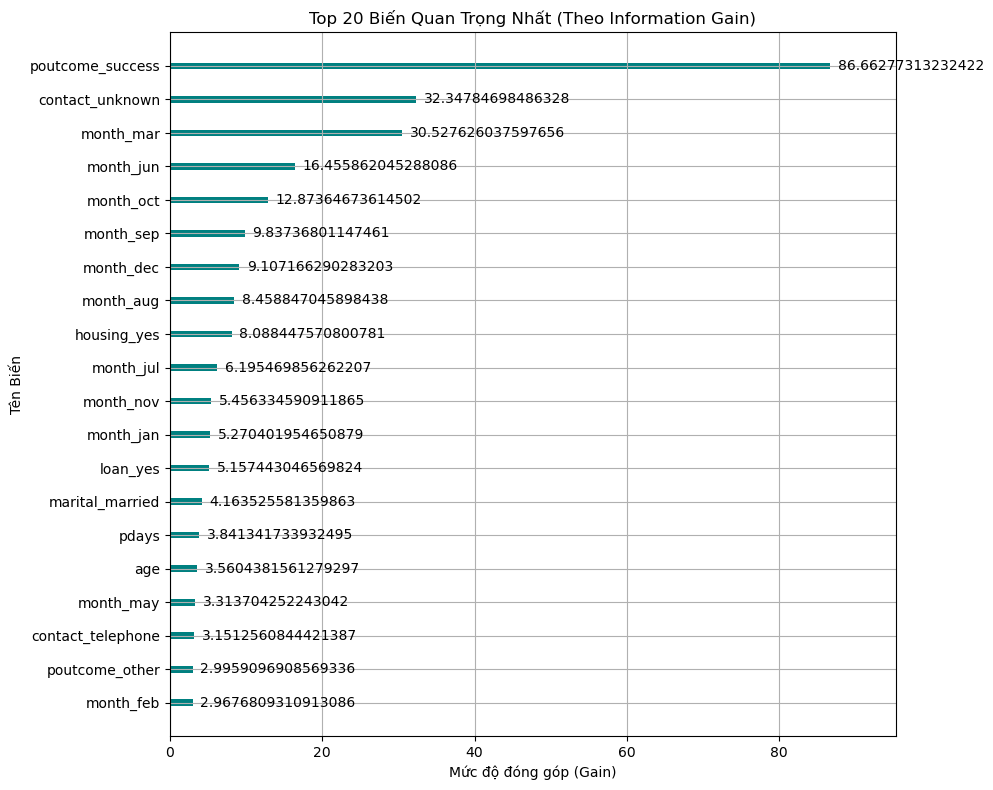

In [57]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Tạo khung hình với kích thước lớn
fig, ax = plt.subplots(figsize=(10, 8))

# 2. DÙNG XGBOOST ĐỂ VẼ BIỂU ĐỒ 
xgb.plot_importance(
    xgb_baseline, 
    ax=ax,                  # Ép biểu đồ vẽ vào khung hình to ở trên
    max_num_features=20, 
    importance_type='gain', # Tiêu chí đo lường chất lượng
    title='Top 20 Biến Quan Trọng Nhất (Theo Information Gain)',
    xlabel='Mức độ đóng góp (Gain)',
    ylabel='Tên Biến',
    color='teal'            # Thêm chút màu cho đẹp mắt
)

plt.tight_layout()
plt.show()

XÁO TRỘN

⏳ Đang tính toán Permutation Importance (Sẽ mất khoảng 10-30 giây)...


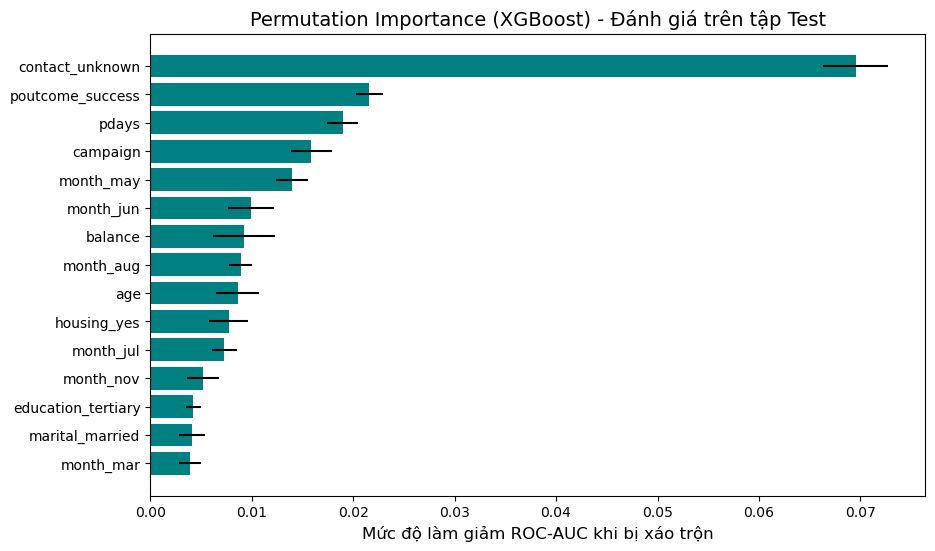

In [55]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang tính toán Permutation Importance (Sẽ mất khoảng 10-30 giây)...")

# Tính toán mức độ giảm điểm ROC-AUC khi xáo trộn từng biến (lặp lại 5 lần để lấy trung bình)
perm_result = permutation_importance(
    xgb_baseline, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=1
)

# Đưa kết quả vào DataFrame cho dễ nhìn
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# Lấy Top 15 biến quan trọng nhất để vẽ
top_perm_df = perm_df.head(15).sort_values(by='Importance_Mean', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(top_perm_df['Feature'], top_perm_df['Importance_Mean'], xerr=top_perm_df['Importance_Std'], color='teal')
plt.title('Permutation Importance (XGBoost) - Đánh giá trên tập Test', fontsize=14)
plt.xlabel('Mức độ làm giảm ROC-AUC khi bị xáo trộn', fontsize=12)
plt.show()

SHAP

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
tensorflow-cpu 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.



INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.8 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 538.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   -- ------------------------------------- 41.0/556.1 kB 1.9 MB/s eta 0:00:01
   ------ --------------------------------- 92.2/556.1 kB 2.6 MB/s eta 0:00:01
   ----------- ---------------------------- 153.6/556.1 kB 1.3 MB/s eta 0:00:01
   ---------------- ----------------------- 225.3/556.1 kB 1.5 MB/s eta 0:00:01
   --------------------------- ------------ 389.1/556.1 kB 1.9 MB/s eta 0:00:01
   ---------------------------------- ----- 481.3/556.1 kB 2.0 MB/s eta 0:00:01
   

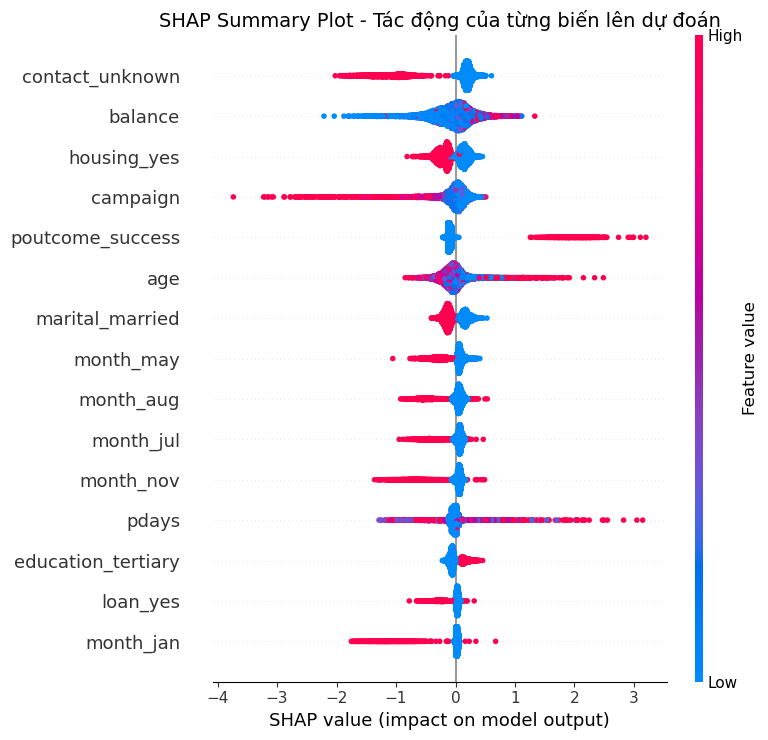

In [56]:
%pip install shap
import shap
import matplotlib.pyplot as plt

print("⏳ Đang tính toán SHAP Values (Có thể mất 1-2 phút tùy cấu hình máy)...")

# 1. Khởi tạo người giải thích (Explainer) chuyên dụng cho mô hình dạng Cây
explainer = shap.TreeExplainer(xgb_baseline)

# 2. Tính toán giá trị SHAP cho toàn bộ tập Test
# (Nếu máy bạn yếu và báo lỗi tràn RAM, hãy thay X_test bằng X_test.sample(1000) để chạy nhanh trên 1000 người thôi)
shap_values = explainer.shap_values(X_test)

# 3. Vẽ biểu đồ Tổng quan (Summary Plot / Beeswarm Plot)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot - Tác động của từng biến lên dự đoán', fontsize=14)

# Lệnh này sẽ tự động vẽ ra một biểu đồ cực kỳ đẹp với các chấm màu
shap.summary_plot(shap_values, X_test, max_display=15, show=False)

plt.tight_layout()
plt.show()